**USER INPUT NAME HANDWRITNG**

GOOGLE FONTS - ANIMATED NAME GIF GENERATOR

 Google Fonts used:
   1. Indie Flower
   2. Cedarville Cursive
   3. Edu NSW ACT Cursive
   4. Tangerine
   5. Petit Formal Script

 Features:
   - User enters a name
   - User selects a Google Font
   - Animated handwriting-style reveal
   - Subtle natural movement
   - GIF preview
   - Automatic GIF download




             GOOGLE FONT NAME GIF GENERATOR

Available Google Fonts:

1. Indie Flower
2. Cedarville Cursive
3. Edu NSW ACT Cursive
4. Tangerine
5. Petit Formal Script


Enter the name you want to animate: Raj
Enter the font number (1-5): 5

Selected name : Raj
Selected font : Petit Formal Script

Google Font downloaded successfully.
Google Font loaded successfully.

Generating animation...

Saving GIF...


                  GIF CREATED
Name : Raj
Font : Petit Formal Script
File : /content/Raj_Petit_Formal_Script.gif


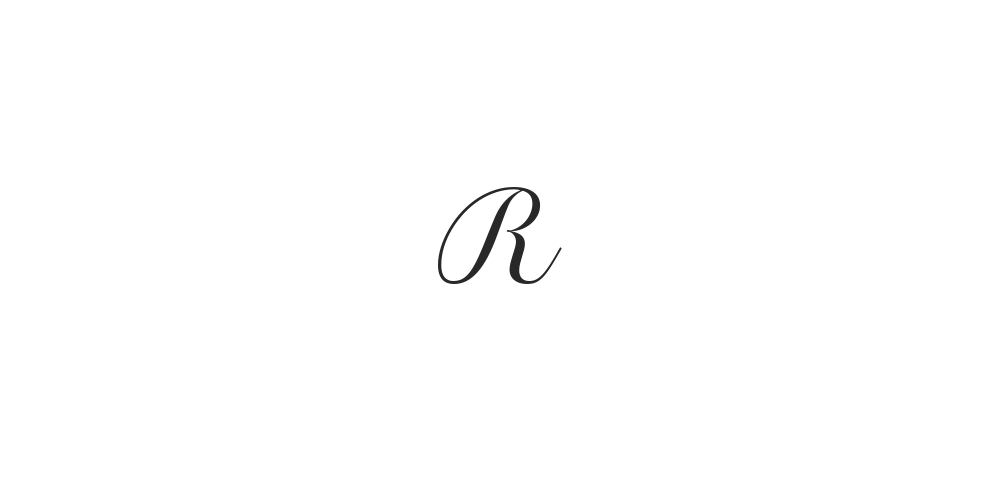

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:


# 1. INSTALL REQUIRED PACKAGES

!pip install -q pillow requests


# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import math
import requests

from PIL import Image, ImageDraw, ImageFont
from google.colab import files
from IPython.display import display


FONT_URLS = {

    "1": {
        "display_name": "Indie Flower",

        "url":
            "https://raw.githubusercontent.com/"
            "google/fonts/main/ofl/indieflower/"
            "IndieFlower-Regular.ttf"
    },


    "2": {
        "display_name": "Cedarville Cursive",

        "url":
            "https://raw.githubusercontent.com/"
            "google/fonts/main/ofl/cedarvillecursive/"
            "CedarvilleCursive-Regular.ttf"
    },


    "3": {
        "display_name": "Edu NSW ACT Cursive",

        "url":
            "https://raw.githubusercontent.com/"
            "google/fonts/main/ofl/edunswactcursive/"
            "EduNSWACTCursive%5Bwght%5D.ttf"
    },


    "4": {
        "display_name": "Tangerine",

        "url":
            "https://raw.githubusercontent.com/"
            "google/fonts/main/ofl/tangerine/"
            "Tangerine-Regular.ttf"
    },


    "5": {
        "display_name": "Petit Formal Script",

        "url":
            "https://raw.githubusercontent.com/"
            "google/fonts/main/ofl/petitformalscript/"
            "PetitFormalScript-Regular.ttf"
    }
}


print("\n")
print("=" * 65)
print("             GOOGLE FONT NAME GIF GENERATOR")
print("=" * 65)

print("\nAvailable Google Fonts:\n")

for number, font_info in FONT_URLS.items():

    print(
        f"{number}. "
        f"{font_info['display_name']}"
    )

print("\n" + "=" * 65)


name = input(
    "\nEnter the name you want to animate: "
).strip()


if not name:

    name = "Your Name"


font_choice = input(
    "Enter the font number (1-5): "
).strip()


# Default to Indie Flower

if font_choice not in FONT_URLS:

    print(
        "\nInvalid selection."
    )

    print(
        "Using Indie Flower."
    )

    font_choice = "1"


selected_font = FONT_URLS[
    font_choice
]

font_name = selected_font[
    "display_name"
]

font_url = selected_font[
    "url"
]


print("\nSelected name :", name)
print("Selected font :", font_name)

# 7. DOWNLOAD GOOGLE FONT
print("\nDownloading Google Font...")


headers = {
    "User-Agent":
        "Mozilla/5.0"
}


response = requests.get(
    font_url,
    headers=headers,
    timeout=30
)

# 8. CHECK DOWNLOAD
if response.status_code != 200:

    print("\nERROR")
    print("-" * 50)

    print(
        "HTTP Status:",
        response.status_code
    )

    print(
        "Font URL:",
        font_url
    )

    raise Exception(
        f"Could not download Google Font: "
        f"{font_name}"
    )

# 9. SAVE FONT
safe_font_name = (
    font_name
    .replace(" ", "_")
)

font_path = (
    "/content/"
    + safe_font_name
    + ".ttf"
)


with open(
    font_path,
    "wb"
) as f:

    f.write(
        response.content
    )


print(
    "Google Font downloaded successfully."
)

# 10. GIF SETTINGS
WIDTH = 1000

HEIGHT = 500

FONT_SIZE = 120

# Number of writing frames

NUM_FRAMES = 45

# Animation speed

FPS = 12

# Duration of each frame

FRAME_DURATION = int(
    1000 / FPS
)


# 11. COLORS
BACKGROUND = (
    255,
    255,
    255
)

TEXT_COLOR = (
    40,
    40,
    40
)

# 12. LOAD GOOGLE FONT
try:

    font = ImageFont.truetype(
        font_path,
        FONT_SIZE
    )

except Exception as e:

    print(
        "\nCould not load the font."
    )

    print(e)

    raise


print(
    "Google Font loaded successfully."
)

# 13. CREATE TEMPORARY IMAGE
temp_image = Image.new(
    "RGB",
    (
        WIDTH,
        HEIGHT
    ),
    BACKGROUND
)


temp_draw = ImageDraw.Draw(
    temp_image
)


# 14. CALCULATE FINAL NAME POSITION
bbox = temp_draw.textbbox(
    (0, 0),
    name,
    font=font
)


text_width = (
    bbox[2] - bbox[0]
)

text_height = (
    bbox[3] - bbox[1]
)


x = (
    WIDTH - text_width
) / 2


y = (
    HEIGHT - text_height
) / 2 - bbox[1]

# 15. CREATE ANIMATION
frames = []


print(
    "\nGenerating animation..."
)


for i in range(
    NUM_FRAMES
):

    # Create frame
    image = Image.new(
        "RGB",
        (
            WIDTH,
            HEIGHT
        ),
        BACKGROUND
    )


    draw = ImageDraw.Draw(
        image
    )


    # --------------------------------------------------------
    # Animation progress
    # --------------------------------------------------------

    progress = (
        i /
        (NUM_FRAMES - 1)
    )


    # --------------------------------------------------------
    # Smooth ease-in-out
    # --------------------------------------------------------

    eased_progress = (
        0.5
        -
        0.5 *
        math.cos(
            math.pi *
            progress
        )
    )


    # --------------------------------------------------------
    # Determine visible characters
    # --------------------------------------------------------

    visible_chars = max(
        1,
        int(
            len(name)
            *
            eased_progress
        )
    )


    visible_text = name[
        :visible_chars
    ]


    # --------------------------------------------------------
    # Calculate visible text size
    # --------------------------------------------------------

    visible_bbox = draw.textbbox(
        (0, 0),
        visible_text,
        font=font
    )


    visible_width = (
        visible_bbox[2]
        -
        visible_bbox[0]
    )


    # --------------------------------------------------------
    # Center text
    # --------------------------------------------------------

    visible_x = (
        WIDTH
        -
        visible_width
    ) / 2


    # --------------------------------------------------------
    # Subtle natural movement
    # --------------------------------------------------------

    movement_x = (
        math.sin(
            progress *
            math.pi *
            2
        )
        *
        1.5
    )


    movement_y = (
        math.sin(
            progress *
            math.pi *
            3
        )
        *
        2
    )


    visible_x += (
        movement_x
    )


    visible_y = (
        y +
        movement_y
    )


    # --------------------------------------------------------
    # Draw text
    # --------------------------------------------------------

    draw.text(

        (
            visible_x,
            visible_y
        ),

        visible_text,

        font=font,

        fill=TEXT_COLOR
    )



    # Store frame

    frames.append(
        image
    )

# 16. HOLD FINAL FRAME
for _ in range(15):

    final_image = Image.new(
        "RGB",
        (
            WIDTH,
            HEIGHT
        ),
        BACKGROUND
    )


    final_draw = ImageDraw.Draw(
        final_image
    )


    final_draw.text(

        (
            x,
            y
        ),

        name,

        font=font,

        fill=TEXT_COLOR
    )


    frames.append(
        final_image
    )


# 17. CREATE SAFE OUTPUT NAME
safe_name = ""


for character in name:

    if character.isalnum():

        safe_name += character

    elif character in (
        " ",
        "_",
        "-"
    ):

        safe_name += "_"

    else:

        safe_name += "_"


output_file = (
    "/content/"
    + safe_name
    + "_"
    + safe_font_name
    + ".gif"
)


# 18. SAVE GIF
print(
    "\nSaving GIF..."
)


frames[0].save(

    output_file,

    save_all=True,

    append_images=frames[1:],

    duration=FRAME_DURATION,

    loop=0,

    optimize=False
)

# 19. DISPLAY GIF IN COLAB
print("\n")
print("=" * 65)
print("                  GIF CREATED")
print("=" * 65)

print(
    "Name :",
    name
)

print(
    "Font :",
    font_name
)

print(
    "File :",
    output_file
)

print("=" * 65)


# Display the GIF

display(
    Image.open(
        output_file
    )
)

# 20. DOWNLOAD GIF
print(
    "\nDownloading GIF..."
)


files.download(
    output_file
)